# ACCESS-OM3 and ACCESS-OM2 timeseries
Includes both scalar variables and spatial averages of 2d variables.

In [1]:
# These first two cells must be in all notebooks!
# It allows us to run all the notebooks at once, this cell has a tag "parameters" which allows us to pass in 
# arguments externally using papermill (see mkfigs.sh for details)

# Set esm_file to the datastore for the main experiment of interest
# esm_file = "/g/data/ol01/outputs/access-om3-25km/25km-iaf-test-for-AK-expt-7df5ef4c/datastore.json"
# esm_file = "/g/data/ol01/outputs/access-om3-25km/MC_25km_jra_iaf-1.0-beta-5165c0f8/datastore.json"
esm_file = "/g/data/ol01/outputs/access-om3-25km/MC_25km_jra_iaf+wombatlite-test3v2-00532b88/datastore.json"

# papermill settings. *No need to modify these if running interactively.* 
papermill = False                      # `cwd` and `nbname` will be populated by papermill.
cwd = None                             # current working directory 
nbname = None                          # notebook name

In [2]:
if not papermill: 
    import nci_ipynb, os  # requires conda/analysis3-26.03 or later
    cwd = nci_ipynb.dir()
    nbname = nci_ipynb.name()
    os.chdir(cwd)
from mkfigs_configdoc import MkmdWriter
mkmd = MkmdWriter(esm_file, nbname, str(cwd), pm=papermill)

In [3]:
%matplotlib inline
import pandas as pd
import intake
import xarray as xr
import numpy as np
import cf_xarray as cfxr
import pint_xarray
from pint import application_registry as ureg
import cf_xarray.units
import cftime
import xgcm
import os

import matplotlib.pyplot as plt
import cmocean as cm
import cartopy.crs as ccrs
import cartopy.feature as cft

from dask.distributed import Client

In [4]:
xr.set_options(keep_attrs=True); # cf_xarray works best when xarray keeps attributes by default

In [5]:
client = Client(threads_per_worker=1)
client

Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 14
Total threads: 14,Total memory: 63.00 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:35443,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:33439,Total threads: 1
Dashboard: /proxy/36505/status,Memory: 4.50 GiB
Nanny: tcp://127.0.0.1:39151,


In [6]:
thisdir = './'

In [7]:
IAF = esm_file.find('iaf') > 0
IAF

True

### Define data sources

In [8]:
catalogs = [
                # '/g/data/ol01/access-om3-output/access-om3-025/25km-iaf-test-for-AK-expt-7df5ef4c/datastore.json',
                '/g/data/ol01/outputs/access-om3-25km/MC_25km_jra_iaf-1.0-beta-5165c0f8/datastore.json',
                esm_file,
                '/g/data/ol01/outputs/access-om3-25km/MC_25km_jra_iaf+wombatlite-test3v2-COARE-12fab415/datastore.json',
            ]
catalogs

['/g/data/ol01/outputs/access-om3-25km/MC_25km_jra_iaf-1.0-beta-5165c0f8/datastore.json',
 '/g/data/ol01/outputs/access-om3-25km/MC_25km_jra_iaf+wombatlite-test3v2-00532b88/datastore.json',
 '/g/data/ol01/outputs/access-om3-25km/MC_25km_jra_iaf+wombatlite-test3v2-COARE-12fab415/datastore.json']

In [9]:
datastores = { os.path.normpath(c).split(os.sep)[-2]:
               intake.open_esm_datastore(c, columns_with_iterables=['variable'])
              for c in catalogs }
datastores

{'MC_25km_jra_iaf-1.0-beta-5165c0f8': <datastore catalog with 22 dataset(s) from 6042 asset(s)>,
 'MC_25km_jra_iaf+wombatlite-test3v2-00532b88': <datastore catalog with 24 dataset(s) from 32927 asset(s)>,
 'MC_25km_jra_iaf+wombatlite-test3v2-COARE-12fab415': <datastore catalog with 24 dataset(s) from 16791 asset(s)>}

In [10]:
# ACCESS-OM2-025 experiment
# use control - see https://forum.access-hive.org.au/t/access-om2-control-experiments/258
if IAF:
    om2expt = '025deg_jra55_iaf_omip2_cycle1'
else:
    om2expt = '025deg_jra55_ryf9091_gadi'
om2cat = intake.cat.access_nri[om2expt]

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.03/lib/python3.12/site-packages/intake/catalog/utils.py:173: UserWarning: Shell command not executed due to getshell=False
  warnings.warn("Shell command not executed due to getshell=False")
/g/data/xp65/public/apps/med_conda/envs/analysis3-26.03/lib/python3.12/site-packages/intake/catalog/utils.py:182: UserWarning: Shell command not executed due to getshell=False
  warnings.warn("Shell command not executed due to getshell=False")


### Load grid data
This is needed for xgcm so we can get spatial averages of non-scalar data.

In [11]:
exptname = os.path.normpath(esm_file).split(os.sep)[-2]
static = xr.open_dataset(datastores[exptname].search(filename="access-om3.mom6.static.nc").df.loc[0, "path"]).drop_vars("time")

In [12]:
# See https://xgcm.readthedocs.io/en/latest/xgcm-examples/03_MOM6/#xgcm-grid-definition
symmetric = True  # True for ACCESS-OM3 2025.08.000 and later

if symmetric:  # ACCESS-OM3 version 2025.08.000 and later: one more q point than h points
    coords={
        'X': {'center': 'xh', 'outer': 'xq'},
        'Y': {'center': 'yh', 'outer': 'yq'},
        # 'Z': { 'inner': 'zl', 'outer': 'zi'}
    }
else:  # ACCESS-OM3 versions prior to 2025.08.000: equal number of q and h points
    coords={
        'X': {'center': 'xh', 'right': 'xq'},
        'Y': {'center': 'yh', 'right': 'yq'},
        # 'Z': { 'inner': 'zl', 'outer': 'zi'}
    }

grid = xgcm.Grid(
    static,
    coords=coords,
    metrics = {
        ('X',): ['dxt', 'dxCu', 'dxCv'], # X distances
        ('Y',): ['dyt', 'dyCu', 'dyCv'], # Y distances
        ('X', 'Y'): ['areacello', 'areacello_cu', 'areacello_cv', 'areacello_bu'] # Areas
    },
    periodic=['X'],
    autoparse_metadata=False
# Note, autoparse_metadata=False is required below for xgcm >= 0.9.0 to prevent xgcm 
# from trying to autoparse non-existent grid information from the file metadata, 
# leading to the error:
# ValueError: Found two coordinates without `c_grid_axis_shift` attribute for axis X
)

### Define list of variables and load them

In [13]:
fields = { # key is OM3 name, value is OM2 name
    # 'mlotst': 'mld',
    # keys from ncdump -h ctrl_run_25km_0.5/archive/output009/access-om3.mom6.scalar.1day.snap.1962.nc | grep double
    'soga': 'salt_global_ave',
    'thetaoga': 'temp_global_ave', # BUG: is OM2 potential temperature? https://github.com/ACCESS-Community-Hub/access-om3-paper-1/issues/3#issuecomment-3736872326
    'tosga': 'temp_surface_ave',   # BUG: is OM2 potential temperature? https://github.com/ACCESS-Community-Hub/access-om3-paper-1/issues/3#issuecomment-3736872326
    'sosga': 'salt_surface_ave',
    'speed_max': None,
    'mlotst_max': None,
    'tos_max': None,
    'tos_min': None,
    'sos_max': None,
    'sos_min': None,
    'zos_max': None,
    'zos_min': None, 
    'total_salt_Flux_Added': None,
    'total_salt_Flux_In': None,
    'total_salt_flux': None,
    'net_fresh_water_global_adjustment': None,
    'salt_flux_global_restoring_adjustment': None,
    'total_wfo': None,
    'total_evs': None,
    'total_fsitherm': None,
    'total_precip': None,
    'total_prsn': None,
    'total_lprec': None,
    'total_ficeberg': None,
    'total_friver': None,
    'total_net_massout': None,
    'total_net_massin': None,
}
fields

{'soga': 'salt_global_ave',
 'thetaoga': 'temp_global_ave',
 'tosga': 'temp_surface_ave',
 'sosga': 'salt_surface_ave',
 'speed_max': None,
 'mlotst_max': None,
 'tos_max': None,
 'tos_min': None,
 'sos_max': None,
 'sos_min': None,
 'zos_max': None,
 'zos_min': None,
 'total_salt_Flux_Added': None,
 'total_salt_Flux_In': None,
 'total_salt_flux': None,
 'net_fresh_water_global_adjustment': None,
 'salt_flux_global_restoring_adjustment': None,
 'total_wfo': None,
 'total_evs': None,
 'total_fsitherm': None,
 'total_precip': None,
 'total_prsn': None,
 'total_lprec': None,
 'total_ficeberg': None,
 'total_friver': None,
 'total_net_massout': None,
 'total_net_massin': None}

In [14]:
# from https://github.com/COSIMA/cosima-recipes/blob/main/Cooking-Lessons-101-Tutorials/ACCESS-NRI_Intake_Catalog.ipynb
# Speeding up opening your datasets
# Try passing the following argument to your to_dask or to_dataset_dict call:
# See the xarray documentation on Reading multi-file datasets for more details about these arguments.
# https://docs.xarray.dev/en/stable/user-guide/io.html#reading-multi-file-datasets

xarray_combine_by_coords_kwargs=dict(
    compat="override",
    data_vars="minimal",
    coords="minimal"
)

In [15]:
# load data, with lots of workarounds for disambiguation
data = dict()
for k, om2 in fields.items():
    print(k)
    # d = [ ds.search(variable=k).to_dataset_dict(xarray_combine_by_coords_kwargs=xarray_combine_by_coords_kwargs) for ds in datastores ]
    try:
        d = { n: ds.search(variable=k) for n, ds in datastores.items() }
        d = { n: ds.to_dask(xarray_combine_by_coords_kwargs=xarray_combine_by_coords_kwargs) for n, ds in d.items() if ds } # avoid .to_dask() for empty datasets
    except ValueError:
        try:
            d = { n: ds.search(variable=k, frequency='1mon', variable_cell_methods='.*time: mean.*') for n, ds in datastores.items() }
            d = { n: ds.to_dask(xarray_combine_by_coords_kwargs=xarray_combine_by_coords_kwargs) for n, ds in d.items() if ds } # avoid .to_dask() for empty datasets
        except:
            try:
                d = { n: ds.search(variable=k, variable_cell_methods='.*time: mean.*') for n, ds in datastores.items() }
                d = { n: ds.to_dask(xarray_combine_by_coords_kwargs=xarray_combine_by_coords_kwargs) for n, ds in d.items() if ds } # avoid .to_dask() for empty datasets
            except:
                try:
                    d = { n: ds.search(variable=k, variable_cell_methods='.*time: point.*') for n, ds in datastores.items() }
                    d = { n: ds.to_dask(xarray_combine_by_coords_kwargs=xarray_combine_by_coords_kwargs) for n, ds in d.items() if ds } # avoid .to_dask() for empty datasets
                except:
                    try:
                        d = { n: ds.search(variable=k, variable_cell_methods='.*time: min.*') for n, ds in datastores.items() }
                        d = { n: ds.to_dask(xarray_combine_by_coords_kwargs=xarray_combine_by_coords_kwargs) for n, ds in d.items() if ds } # avoid .to_dask() for empty datasets
                    except:
                        try:
                            d = { n: ds.search(variable=k, variable_cell_methods='.*time: max.*') for n, ds in datastores.items() }
                            d = { n: ds.to_dask(xarray_combine_by_coords_kwargs=xarray_combine_by_coords_kwargs) for n, ds in d.items() if ds } # avoid .to_dask() for empty datasets
                        except:
                            print(f'{k} failed')
                            continue
    if om2 is None: # add access-om2 data,with variable name changed to match om3
        d2 = {}
    else:
        # d[om2expt] = om2cat.search(variable=om2).to_dask().rename({om2: k})
        d2 = {om2expt: om2cat.search(variable=om2, frequency=d[list(d.keys())[0]].attrs['intake_esm_attrs:frequency']).to_dask().rename({om2: k})}
    # if d:
    #     data[k] = xr.concat(d, 'time')
    # else:
    #     print(f'no data for {k}')
    # break
    data[k] = d2 | d
    # break

if IAF:
    for vname, d in data.items():
        for expt in d.keys():
            try:
                d[expt] = d[expt].convert_calendar("proleptic_gregorian", use_cftime=True)
            except KeyError:
                pass
data

soga


/g/data/xp65/public/apps/med_conda/envs/analysis3-26.03/lib/python3.12/site-packages/intake_esm/core.py:321: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  records = grouped.get_group(internal_key).to_dict(orient='records')


thetaoga


/g/data/xp65/public/apps/med_conda/envs/analysis3-26.03/lib/python3.12/site-packages/intake_esm/core.py:321: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  records = grouped.get_group(internal_key).to_dict(orient='records')


tosga


...

total_net_massout


/g/data/xp65/public/apps/med_conda/envs/analysis3-26.03/lib/python3.12/site-packages/intake_esm/core.py:321: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  records = grouped.get_group(internal_key).to_dict(orient='records')


total_net_massin


/g/data/xp65/public/apps/med_conda/envs/analysis3-26.03/lib/python3.12/site-packages/intake_esm/core.py:321: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  records = grouped.get_group(internal_key).to_dict(orient='records')


{'soga': {'025deg_jra55_iaf_omip2_cycle1': <xarray.Dataset> Size: 356kB
  Dimensions:      (time: 22280, scalar_axis: 1)
  Coordinates:
    * time         (time) object 178kB 1957-12-31 00:00:00 ... 2018-12-30 00:00:00
    * scalar_axis  (scalar_axis) float64 8B 0.0
  Data variables:
      soga         (time, scalar_axis) float64 178kB dask.array<chunksize=(365, 1), meta=np.ndarray>
  Attributes: (12/17)
      filename:                                 ocean_scalar_snapshot.nc
      title:                                    ACCESS-OM2
      grid_type:                                mosaic
      grid_tile:                                1
      intake_esm_vars:                          ['salt_global_ave']
      intake_esm_attrs:filename:                ocean_scalar_snapshot.nc
      ...                                       ...
      intake_esm_attrs:variable_cell_methods:   time: point,time: point,time: p...
      intake_esm_attrs:variable_units:          meter,10^15 Joules,10^15 Joules

In [16]:
data.keys()

dict_keys(['soga', 'thetaoga', 'tosga', 'sosga', 'speed_max', 'mlotst_max', 'tos_max', 'tos_min', 'sos_max', 'sos_min', 'zos_max', 'zos_min', 'total_salt_Flux_Added', 'total_salt_Flux_In', 'total_salt_flux', 'net_fresh_water_global_adjustment', 'salt_flux_global_restoring_adjustment', 'total_wfo', 'total_evs', 'total_fsitherm', 'total_precip', 'total_prsn', 'total_lprec', 'total_ficeberg', 'total_friver', 'total_net_massout', 'total_net_massin'])

In [17]:
data

{'soga': {'025deg_jra55_iaf_omip2_cycle1': <xarray.Dataset> Size: 356kB
  Dimensions:      (time: 22280, scalar_axis: 1)
  Coordinates:
    * time         (time) object 178kB 1957-12-31 00:00:00 ... 2018-12-30 00:00:00
    * scalar_axis  (scalar_axis) float64 8B 0.0
  Data variables:
      soga         (time, scalar_axis) float64 178kB dask.array<chunksize=(365, 1), meta=np.ndarray>
  Attributes: (12/17)
      filename:                                 ocean_scalar_snapshot.nc
      title:                                    ACCESS-OM2
      grid_type:                                mosaic
      grid_tile:                                1
      intake_esm_vars:                          ['salt_global_ave']
      intake_esm_attrs:filename:                ocean_scalar_snapshot.nc
      ...                                       ...
      intake_esm_attrs:variable_cell_methods:   time: point,time: point,time: p...
      intake_esm_attrs:variable_units:          meter,10^15 Joules,10^15 Joules

### Plot timeseries

In [18]:
# set date range
# trange = slice(cftime.DatetimeNoLeap(1900, 1, 1, 0, 0, 0, 0),
#                cftime.DatetimeNoLeap(1960, 1, 1, 0, 0, 0, 0))
trange = slice(None, None)  # all available

soga
thetaoga
tosga
sosga
speed_max
mlotst_max
tos_max
tos_min
sos_max
sos_min
zos_max
zos_min
total_salt_Flux_Added
total_salt_Flux_In
total_salt_flux
net_fresh_water_global_adjustment
salt_flux_global_restoring_adjustment
total_wfo
total_evs
total_fsitherm
total_precip


/jobfs/168060902.gadi-pbs/ipykernel_101221/3423850955.py:8: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure(figsize=(10,5))


total_prsn
total_lprec
total_ficeberg
total_friver
total_net_massout
total_net_massin


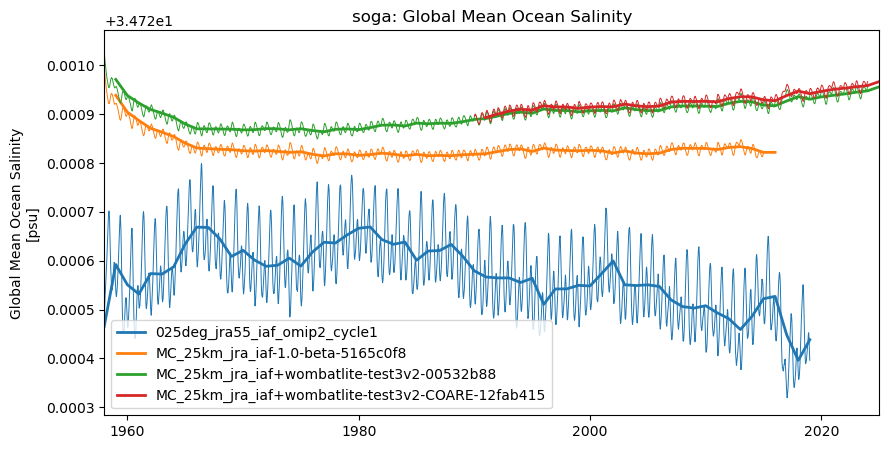

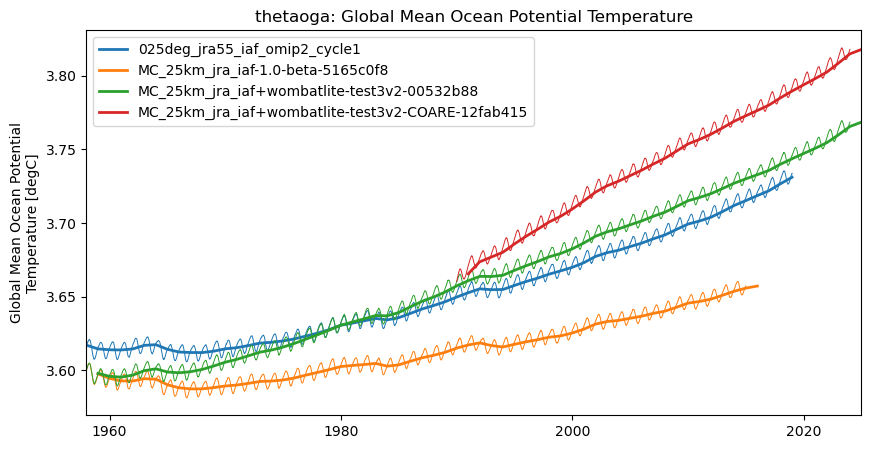

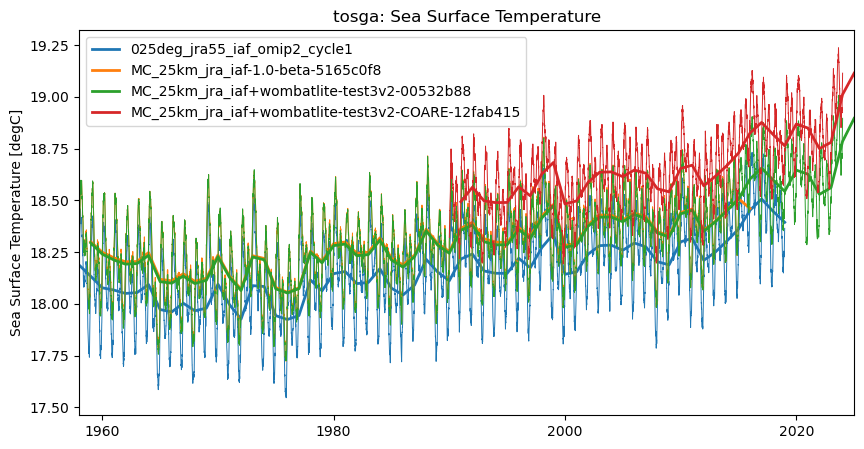

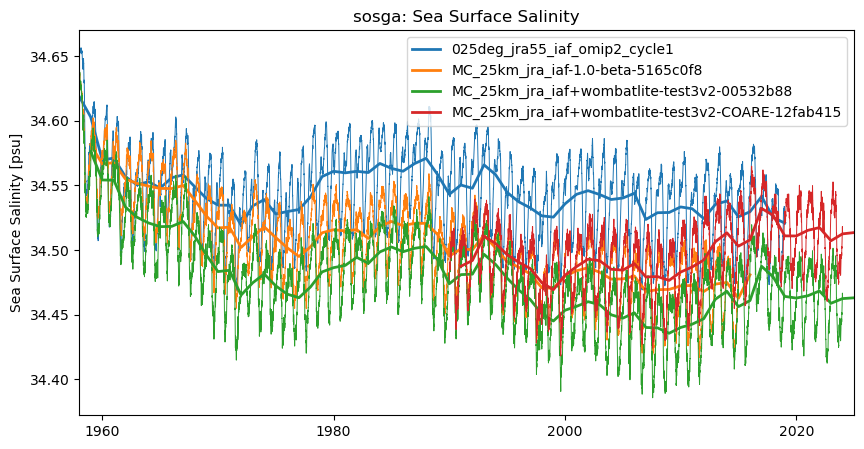

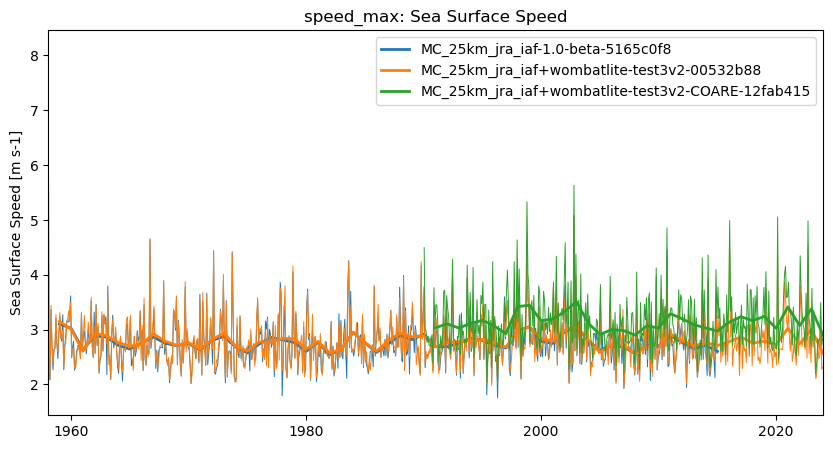

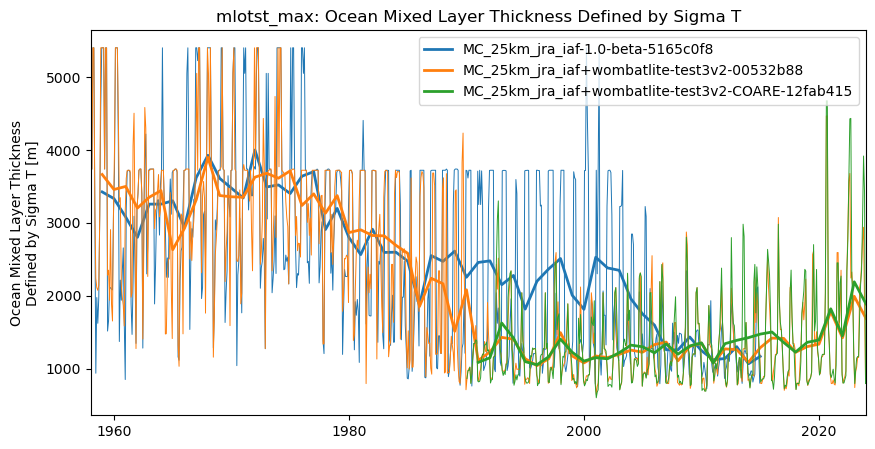

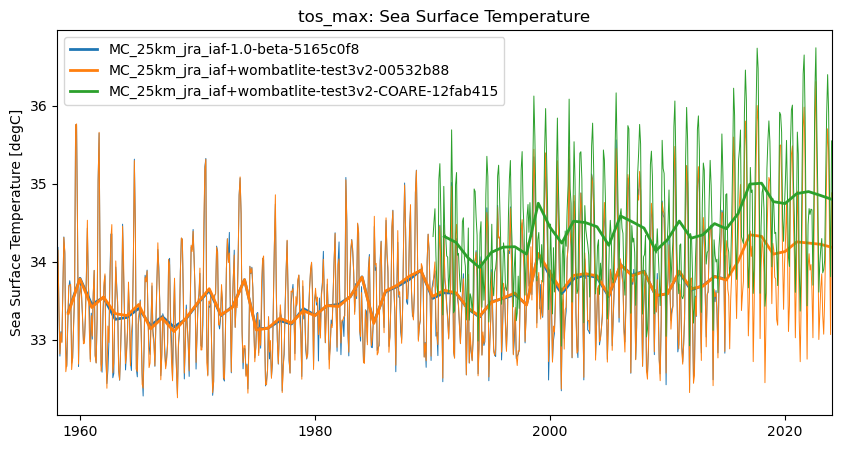

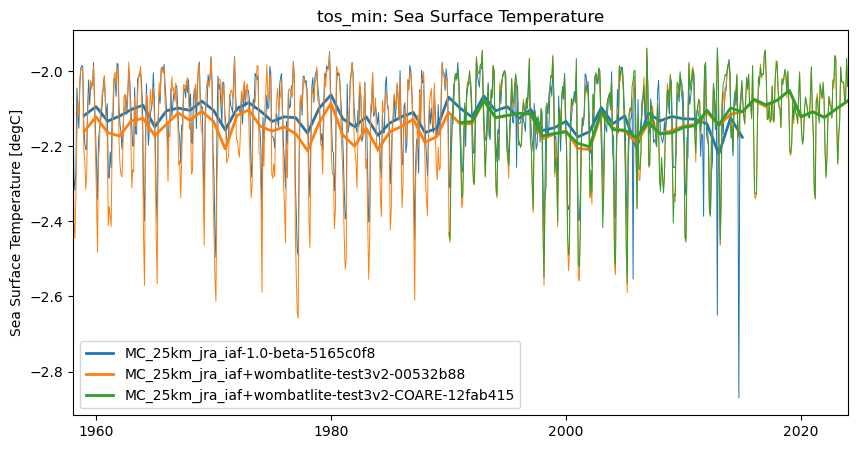

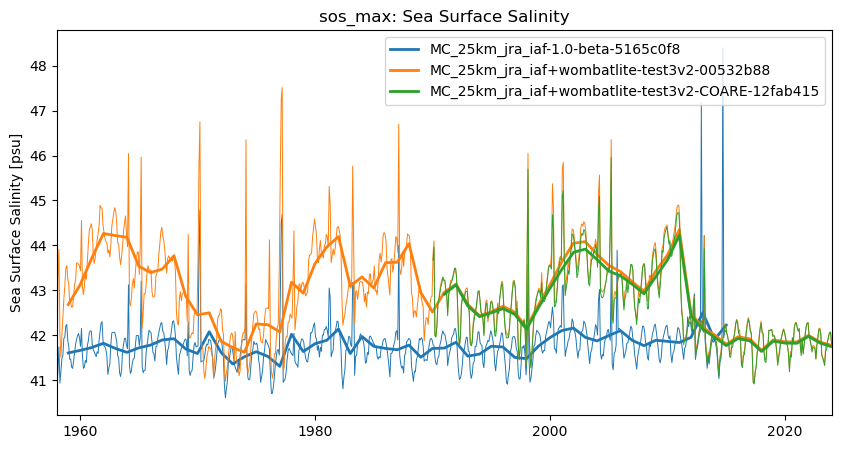

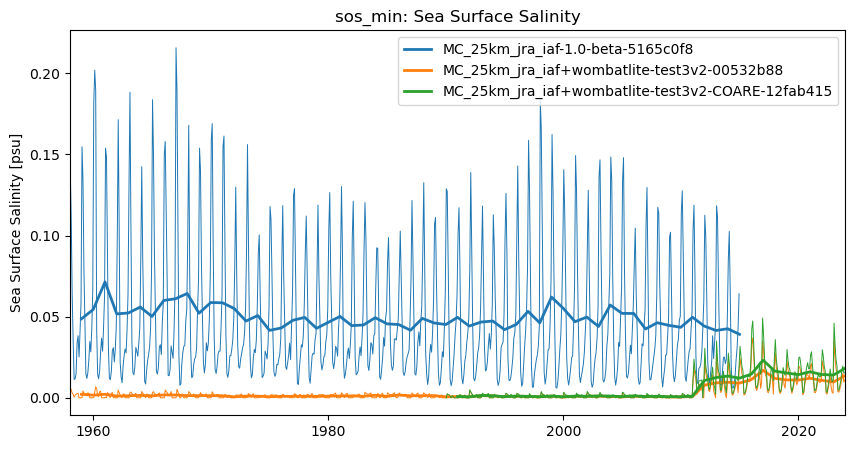

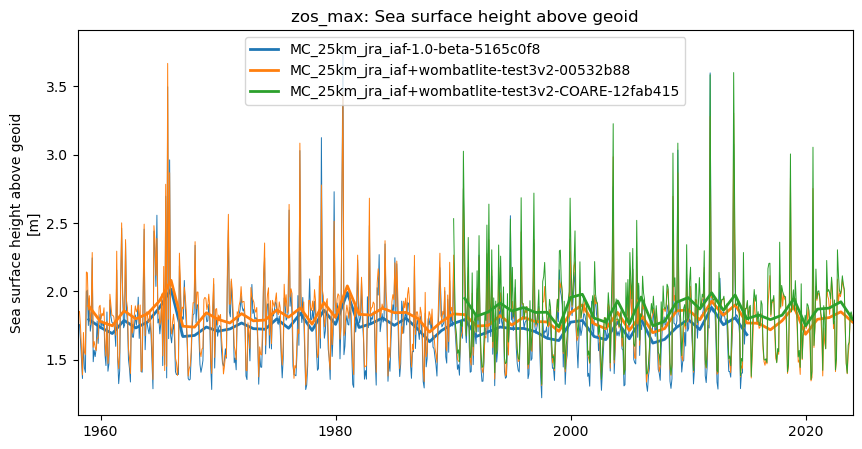

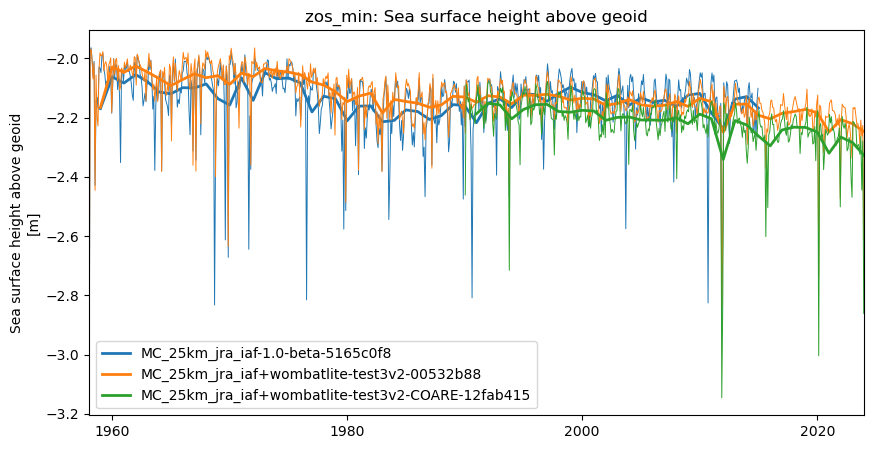

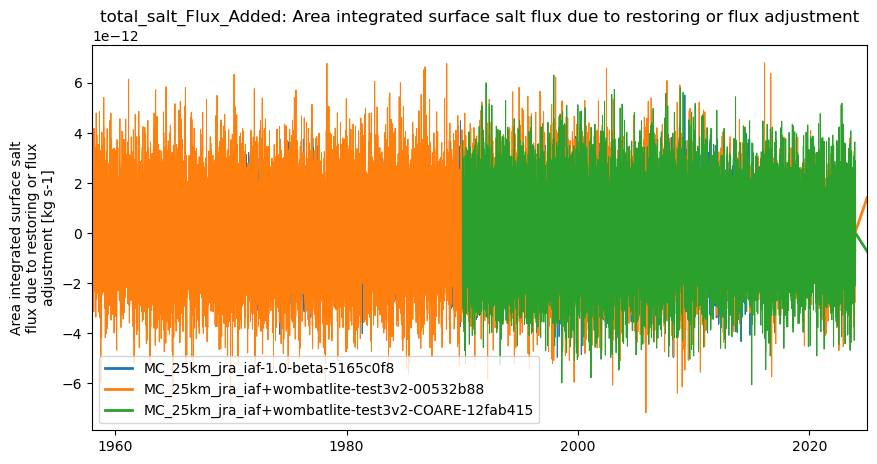

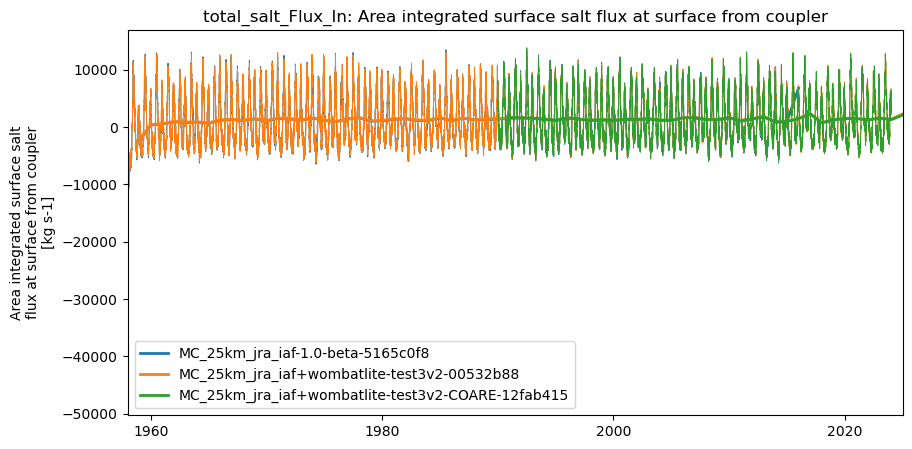

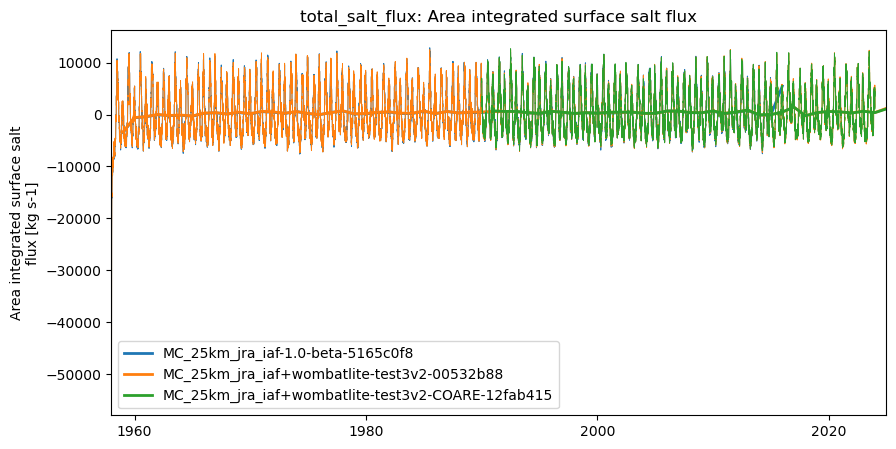

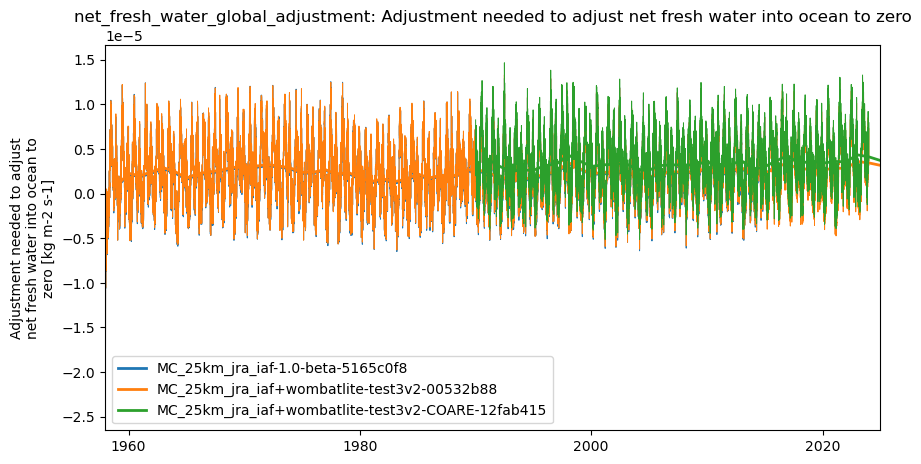

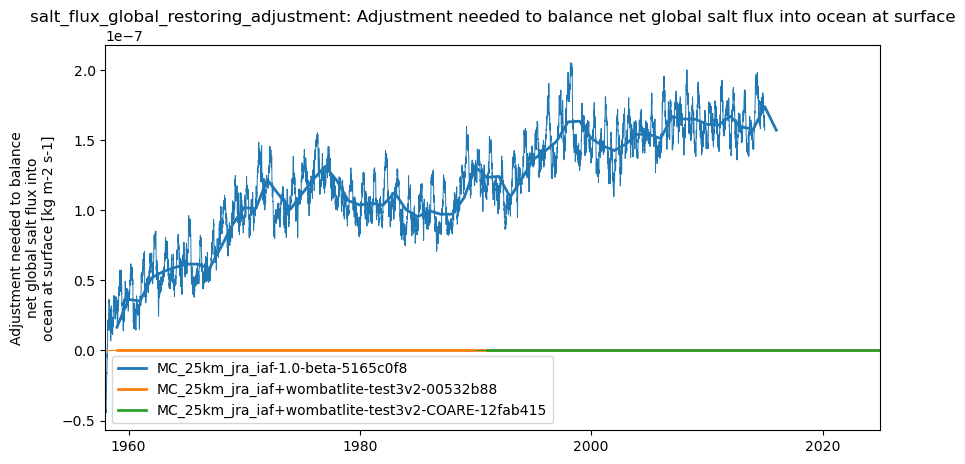

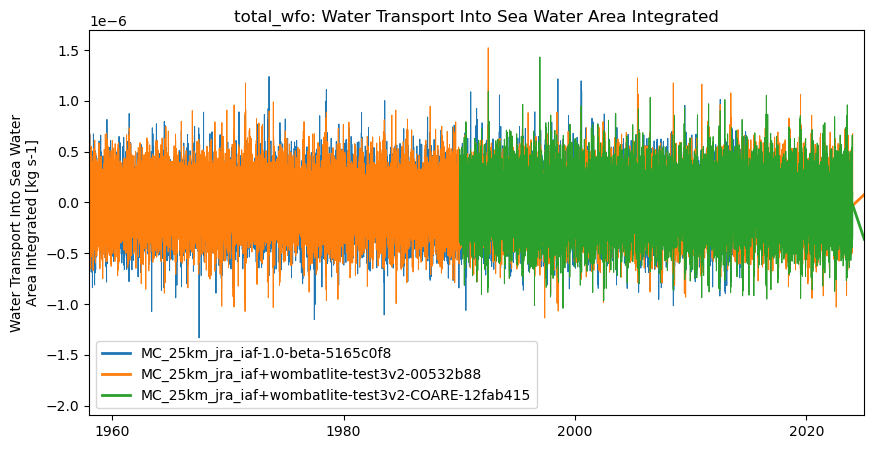

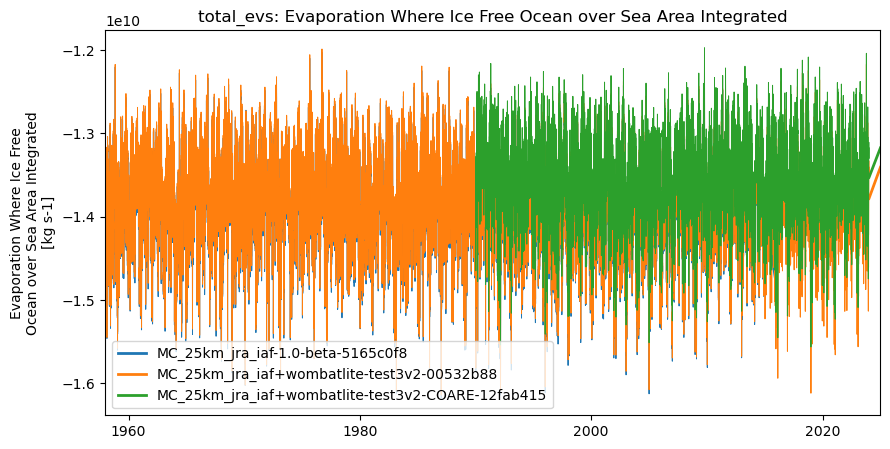

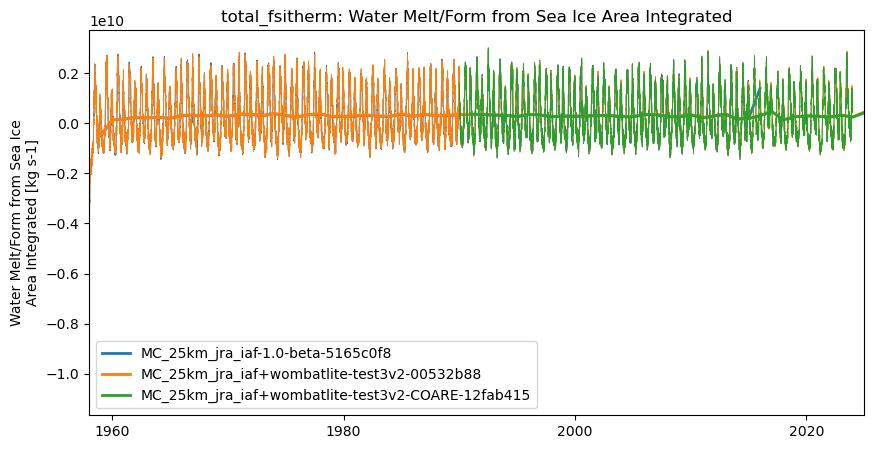

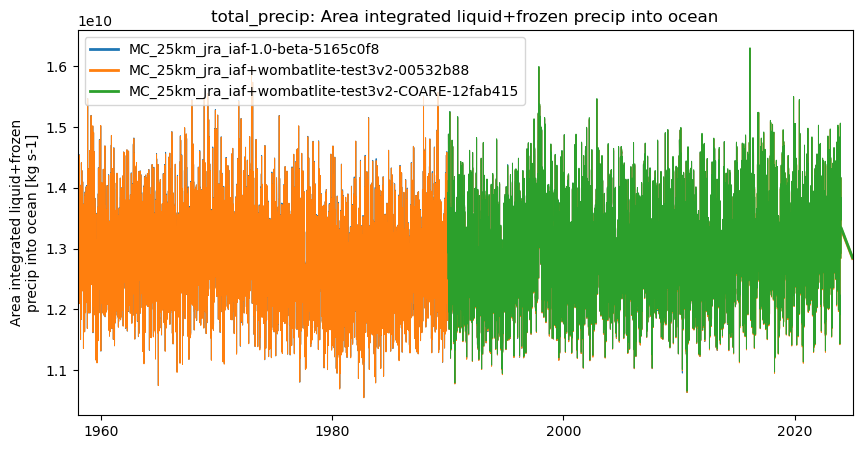

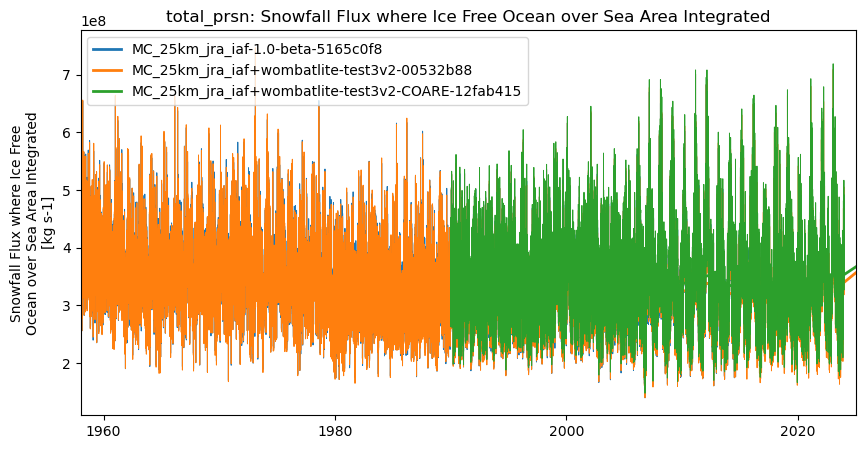

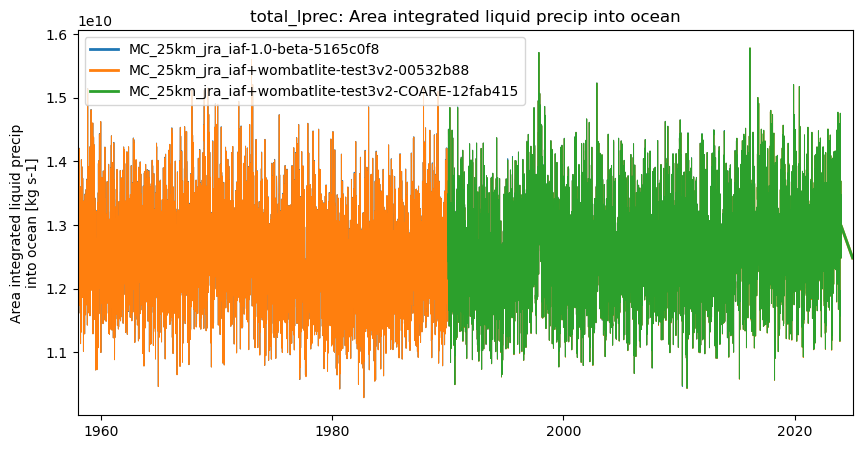

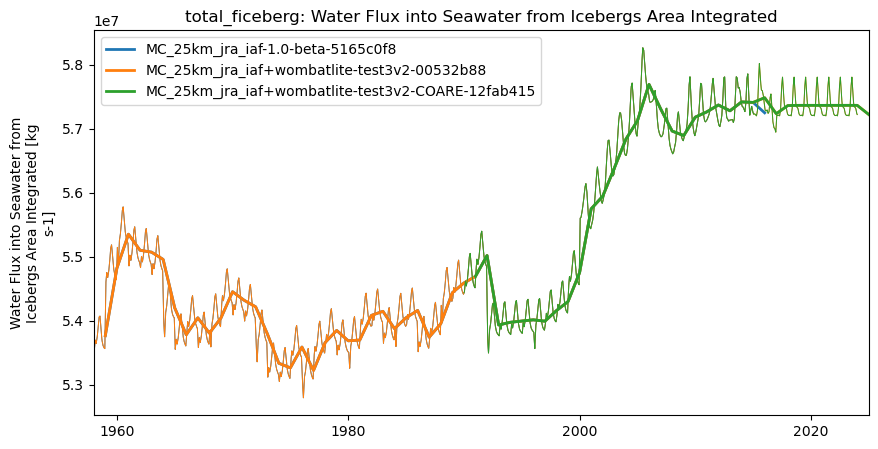

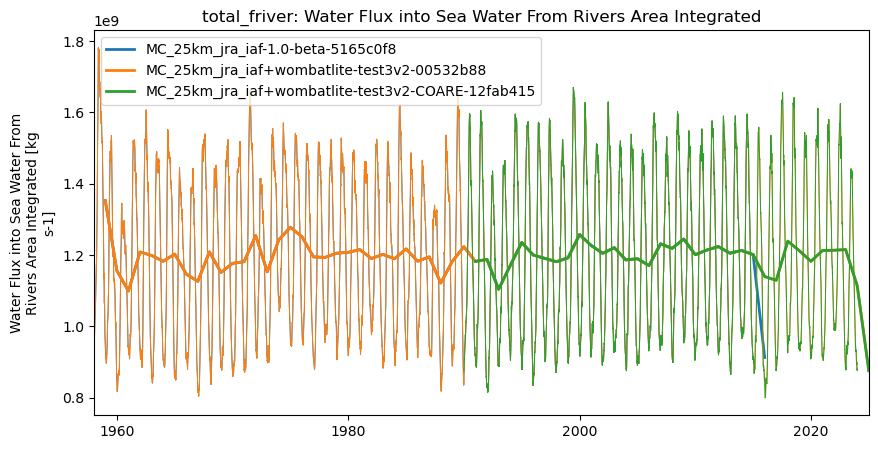

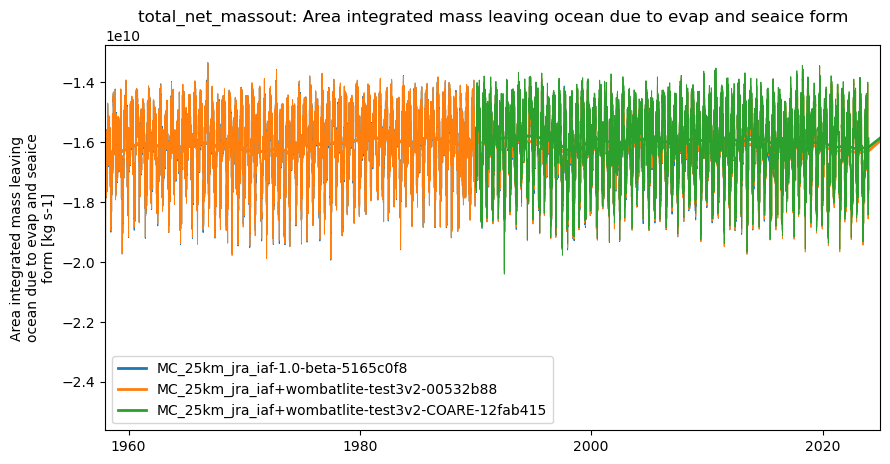

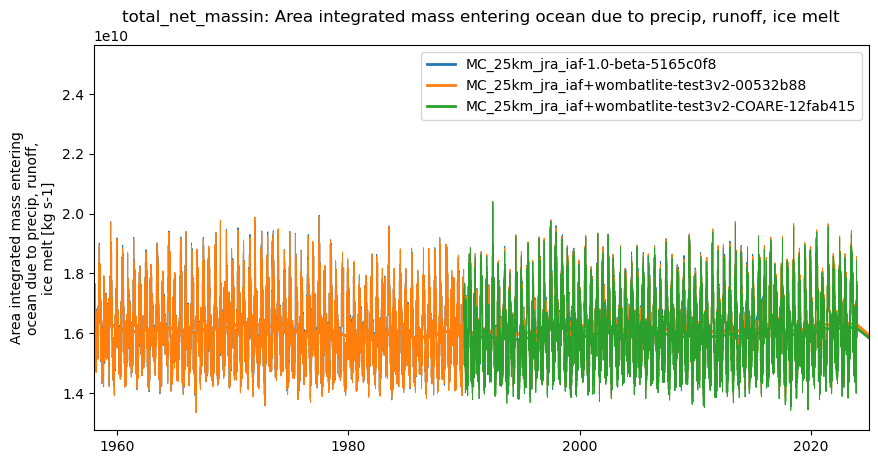

In [19]:
for k, d in data.items():
    print(k)
    fname = thisdir+k+'_'+list(d.values())[-1][k].attrs['long_name'].replace(' ', '_').replace('/','_')+'.png'
    # print(fname)
    if False: #os.path.isfile(fname):
        print(f'---- skipping existing file {fname}')
    else:
        plt.figure(figsize=(10,5))
        ax = plt.subplot(111)
        for n, ds in d.items():
            dat = ds[k].sel(time=trange)
            if dat.cell_methods.find('time: mean') >= 0:
                # calculate spatial average if needed
                if 'depth' in dat.cf.coords: # https://xgcm.readthedocs.io/en/latest/grid_metrics.html?highlight=average#Grid-aware-(weighted)-average
                    dat = grid.average(dat, ['X', 'Y', 'Z'])
                elif 'longitude' in dat.cf.coords: # https://xgcm.readthedocs.io/en/latest/grid_metrics.html?highlight=average#Grid-aware-(weighted)-average
                    dat = grid.average(dat, ['X', 'Y'])
            elif dat.cell_methods.find('time: max') >= 0:
                dat = dat.cf.max(dim=['longitude', 'latitude'])
            elif dat.cell_methods.find('time: min') >= 0:
                dat = dat.cf.min(dim=['longitude', 'latitude'])
            # dat = dat - dat.isel(time=0)
            dat.load()
            # if int((dat.time[1]-dat.time[0]).values/1e9/60/60/24) == 1:
            #     label = 'daily'
            # else:
            #     label = 'monthly mean' # possible BUG: plausible guess
            # p = dat.plot(label=' '.join([n, label]), linewidth=1)
            p = dat.plot(linewidth=.7)
            dat.cf.resample(time='1YE').mean('time').plot(
                color=p[-1].get_color(),
                linewidth=2,
                label=n
            )
            # dat.cf.rolling(time=12, center=True).mean('time').plot()
            # dat.cf.rolling(time='1YE', center=True).mean('time').plot()
        # NB: title from first item (OM3), but y axis label from last item (may be OM2)
        # plt.title(k+': '+list(d.values())[0][k].attrs['long_name'])
        plt.title(f'{k}: {dat.attrs["long_name"]}')
        plt.xlabel('')
        plt.autoscale(enable=True, axis='x', tight=True)
        plt.legend()
        # # Shrink current axis's height from the bottom
        # box = ax.get_position()
        # ax.set_position([box.x0, box.y0 + box.height * 0.4,
        #                  box.width, box.height * 0.6])
        # # Put a legend below current axis
        # ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.08))
        # # try:
        #     plt.savefig(fname, dpi=150)
        #     print(f'saved {fname}')
        # except FileNotFoundError:
        #     print(f'*** FileNotFoundError when saving {fname}')
        # break
    mkmd.savefig("Timeseries", "")

soga


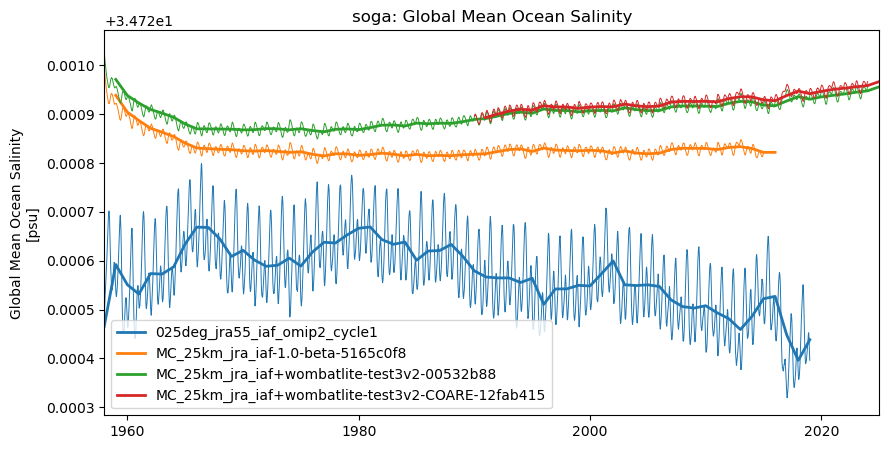

In [20]:
# just plot soga, omitting 25km-iaf-test-for-AK-expt-7df5ef4c
for k, d in data.items():
    if k != "soga":
        continue
    print(k)
    fname = thisdir+k+'_'+list(d.values())[-1][k].attrs['long_name'].replace(' ', '_').replace('/','_')+'.png'
    # print(fname)
    if False: #os.path.isfile(fname):
        print(f'---- skipping existing file {fname}')
    else:
        plt.figure(figsize=(10,5))
        ax = plt.subplot(111)
        for n, ds in d.items():
            if n == "25km-iaf-test-for-AK-expt-7df5ef4c":
                continue
            dat = ds[k].sel(time=trange)
            if dat.cell_methods.find('time: mean') >= 0:
                # calculate spatial average if needed
                if 'depth' in dat.cf.coords: # https://xgcm.readthedocs.io/en/latest/grid_metrics.html?highlight=average#Grid-aware-(weighted)-average
                    dat = grid.average(dat, ['X', 'Y', 'Z'])
                elif 'longitude' in dat.cf.coords: # https://xgcm.readthedocs.io/en/latest/grid_metrics.html?highlight=average#Grid-aware-(weighted)-average
                    dat = grid.average(dat, ['X', 'Y'])
            elif dat.cell_methods.find('time: max') >= 0:
                dat = dat.cf.max(dim=['longitude', 'latitude'])
            elif dat.cell_methods.find('time: min') >= 0:
                dat = dat.cf.min(dim=['longitude', 'latitude'])
            # dat = dat - dat.isel(time=0)
            dat.load()
            # if int((dat.time[1]-dat.time[0]).values/1e9/60/60/24) == 1:
            #     label = 'daily'
            # else:
            #     label = 'monthly mean' # possible BUG: plausible guess
            # p = dat.plot(label=' '.join([n, label]), linewidth=1)
            p = dat.plot(linewidth=.7)
            dat.cf.resample(time='1YE').mean('time').plot(
                color=p[-1].get_color(),
                linewidth=2,
                label=n
            )
            # dat.cf.rolling(time=12, center=True).mean('time').plot()
            # dat.cf.rolling(time='1YE', center=True).mean('time').plot()
        # NB: title from first item (OM3), but y axis label from last item (may be OM2)
        # plt.title(k+': '+list(d.values())[0][k].attrs['long_name'])
        plt.title(f'{k}: {dat.attrs["long_name"]}')
        plt.xlabel('')
        plt.autoscale(enable=True, axis='x', tight=True)
        plt.legend()
        # # Shrink current axis's height from the bottom
        # box = ax.get_position()
        # ax.set_position([box.x0, box.y0 + box.height * 0.4,
        #                  box.width, box.height * 0.6])
        # # Put a legend below current axis
        # ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.08))
        # # try:
        #     plt.savefig(fname, dpi=150)
        #     print(f'saved {fname}')
        # except FileNotFoundError:
        #     print(f'*** FileNotFoundError when saving {fname}')
        # break

## Water balance checks

https://github.com/ACCESS-NRI/access-om3-configs/issues/920

In [21]:
esm_name = os.path.normpath(esm_file).split(os.sep)[-2]
esm_name

'MC_25km_jra_iaf+wombatlite-test3v2-00532b88'

In [22]:
masked_areacello = static['areacello'] + 0*data['tos_max'][esm_name].tos_max.isel(time=0)

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.03/lib/python3.12/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 12.77 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


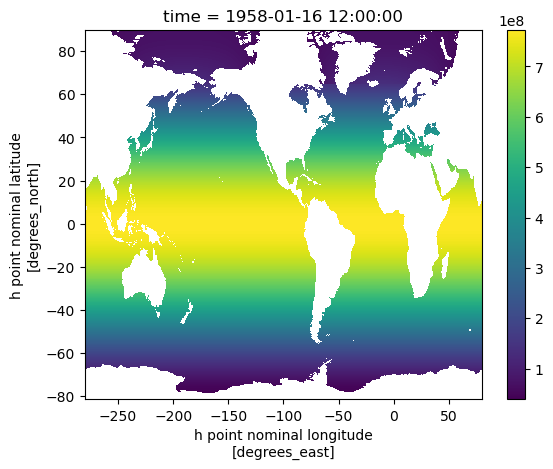

In [23]:
masked_areacello.plot()

In [24]:
total_ocean_area = masked_areacello.sum().load()

/g/data/xp65/public/apps/med_conda/envs/analysis3-26.03/lib/python3.12/site-packages/distributed/client.py:3387: UserWarning: Sending large graph of size 12.77 MiB.
This may cause some slowdown.
Consider loading the data with Dask directly
 or using futures or delayed objects to embed the data into the graph without repetition.
See also https://docs.dask.org/en/stable/best-practices.html#load-data-with-dask for more information.
  warnings.warn(


In [25]:
net_fresh_water_global_adjustment = (data['net_fresh_water_global_adjustment'][esm_name]['net_fresh_water_global_adjustment'] * total_ocean_area).load()

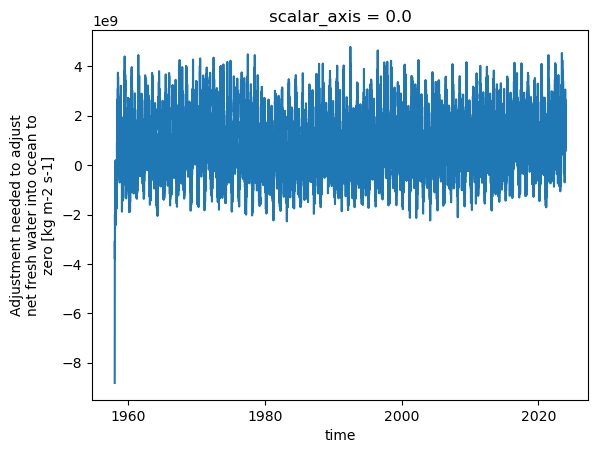

In [26]:
net_fresh_water_global_adjustment.plot()

In [27]:
total_fsitherm = data['total_fsitherm'][esm_name]['total_fsitherm'].load()

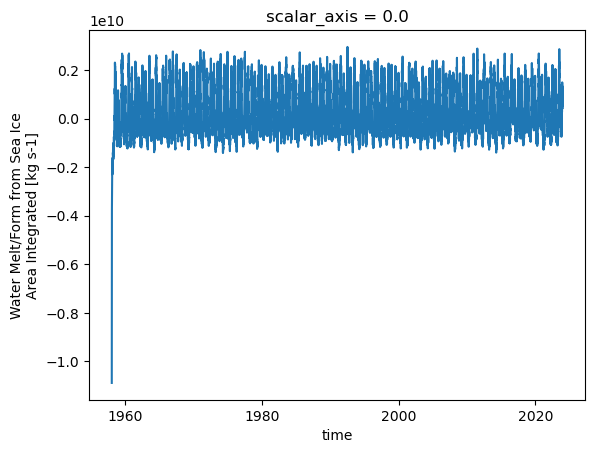

In [28]:
total_fsitherm.plot()

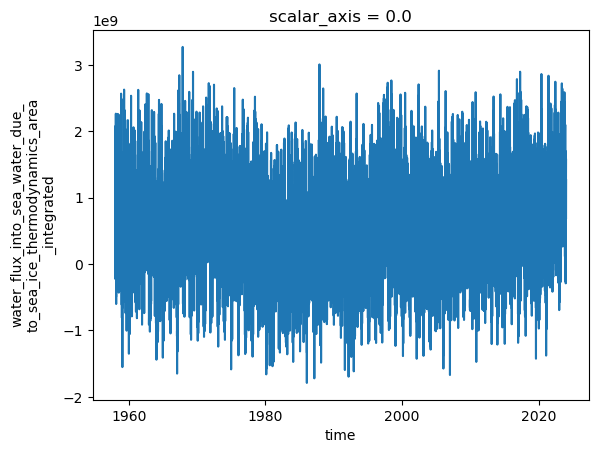

In [29]:
(net_fresh_water_global_adjustment - total_fsitherm).plot()